# Feature Selection and Deduplication

**Chapter 8: Feature Engineering**
**Section Reference**: 8.6 — Combining Features and Controlling Search

**Docker image**: `ml4t`

## Purpose

A feature engineering pipeline produces many candidates — different lookbacks,
transforms, and interaction variants. This notebook demonstrates how to reduce
that set to a focused, production-ready collection using systematic selection
and deduplication.

## Learning Objectives

1. Compute cross-sectional IC and rank features by predictive power
2. Apply correlation filtering to remove redundant features
3. Cluster near-duplicate features and select representatives
4. Use Benjamini–Hochberg FDR to control false discovery across multiple tests
5. Assess feature stability via bootstrap IC
6. Compare IC-based and ML-based (LightGBM) importance rankings

## Prerequisites

- Run [`03_financial_features`](../case_studies/etfs/03_financial_features.ipynb)
  to produce `financial.parquet`
- Requires `ml4t-diagnostic` and `ml4t-engineer` libraries

## References

- Harvey, Liu, and Zhu (2016) — Multiple testing in factor research
- Meinshausen and Bühlmann (2010) — Stability selection

**Output**: Selected feature list for downstream Chapter 9 use

## Setup

In [1]:
"""Feature Selection and Deduplication — reduce feature candidates to a focused production-ready set."""

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import yaml
from ml4t.diagnostic.metrics import pooled_ic
from scipy.cluster.hierarchy import fcluster, leaves_list, linkage
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")

from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
START_DATE = "2006-01-01"
N_BOOTSTRAP = 50
MAX_SYMBOLS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Load Features from ETF Case Study

The ETF case study produced features in `case_studies/etfs/features/`.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"

if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Features file not found at {FEATURES_PATH}. "
        "Please run case_studies/etfs/03_financial_features.py first."
    )

features_df = pl.read_parquet(FEATURES_PATH)
prices_df = load_etfs()

# Holdout boundary: feature selection is a development decision, and the
# sealed holdout (setup.yaml `evaluation.holdout_start`; see the rule in
# 06_strategy_definition/02_cv_foundations) must not inform it. Every step
# below — IC ranking, BH-FDR, stability selection, ML importance — sees only
# pre-holdout rows, and the forward-return labels computed from the filtered
# prices never span into the holdout.
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])

# Apply date filters: development window only ([START_DATE, HOLDOUT_START))
features_df = features_df.filter(
    (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") < HOLDOUT_START)
)
prices_df = prices_df.filter(
    (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") < HOLDOUT_START)
)

if MAX_SYMBOLS > 0:
    top_symbols = (
        features_df.group_by("symbol")
        .len()
        .sort("len", descending=True)
        .head(MAX_SYMBOLS)["symbol"]
    )
    features_df = features_df.filter(pl.col("symbol").is_in(top_symbols))
    prices_df = prices_df.filter(pl.col("symbol").is_in(top_symbols))

# Compute forward returns on-demand
labels_df = (
    prices_df.sort(["symbol", "timestamp"])
    .with_columns(
        (pl.col("close").shift(-21).over("symbol") / pl.col("close") - 1).alias("fwd_return_1m")
    )
    .select(["timestamp", "symbol", "fwd_return_1m"])
    .drop_nulls()
)

print(f"Features: {features_df.shape}")
print(f"Labels: {labels_df.shape}")
print(f"Development window: {START_DATE} to {HOLDOUT_START} (holdout sealed)")

Features: (92101, 59)
Labels: (418362, 3)
Development window: 2006-01-01 to 2024-01-01 (holdout sealed)


In [5]:
all_feature_cols = [c for c in features_df.columns if c not in ["timestamp", "symbol"]]

# Replace non-finite feature values (e.g. 0/0 in short-window Sharpe ratios)
# with nulls. Left in place they survive drop_nulls (which removes only nulls)
# and propagate NaN through pl.corr and the panel correlation matrix, poisoning
# the affected features' correlations and misgrouping them in the clustering.
features_df = features_df.with_columns(
    [
        pl.when(pl.col(c).is_finite()).then(pl.col(c)).otherwise(None).alias(c)
        for c in all_feature_cols
    ]
)

print(f"Available features: {len(all_feature_cols)}")
for i, col in enumerate(all_feature_cols, 1):
    print(f"  {i:2d}. {col}")

Available features: 57
   1. ret_5d
   2. ret_10d
   3. ret_21d
   4. ret_42d
   5. ret_63d
   6. ret_126d
   7. ret_189d
   8. ret_252d
   9. skip_recent_12_1
  10. skip_recent_6_1
  11. vol_21d
  12. vol_63d
  13. vol_126d
  14. vol_252d
  15. sharpe_5d
  16. sharpe_10d
  17. sharpe_21d
  18. sharpe_42d
  19. sharpe_63d
  20. sharpe_126d
  21. sharpe_189d
  22. sharpe_252d
  23. mom_accel_short
  24. mom_accel_medium
  25. mom_accel_long
  26. vol_ratio_short
  27. vol_ratio_medium
  28. rsi_7
  29. rsi_14
  30. macd_line
  31. adx_14
  32. cci_14
  33. cci_21
  34. stoch_k
  35. aroon_diff
  36. sma_ratio_50
  37. sma_ratio_200
  38. ema_ratio_26
  39. bb_pctb_20
  40. natr_14
  41. chop_14
  42. hurst_100
  43. max_dd_63d
  44. max_dd_126d
  45. vol_ratio_21d
  46. vol_ratio_63d
  47. obv_zscore_63d
  48. pct_positive_63d
  49. dist_52w_high
  50. dist_52w_low
  51. corr_spy_tlt_63d
  52. ret_126d_rank
  53. sharpe_126d_rank
  54. vol_63d_rank
  55. regime
  56. yield_curve_slope
 

## 2. Compute Information Coefficient (IC)

IC measures the Spearman rank correlation between features and forward returns.
We compute IC **cross-sectionally** (per date, then average). Pooled IC
conflates time-series drift with cross-sectional predictive power.

In [6]:
# Merge features with forward returns
analysis = features_df.join(
    labels_df.select(["timestamp", "symbol", "fwd_return_1m"]),
    on=["timestamp", "symbol"],
    how="inner",
).drop_nulls(subset=["fwd_return_1m"])

print(f"Analysis dataset: {analysis.shape}")

Analysis dataset: (91639, 60)


In [7]:
# Compute cross-sectional IC per date. Sort by timestamp: ``group_by`` does not
# preserve order, and the Newey-West HAC t-stat below regresses each feature's
# daily IC series on a constant with an autocovariance correction, which is only
# meaningful on a chronologically ordered series.
ic_by_date = (
    analysis.group_by("timestamp")
    .agg([pl.corr(col, "fwd_return_1m", method="spearman").alias(col) for col in all_feature_cols])
    .sort("timestamp")
)

# Summary statistics. The daily IC series is serially correlated (overlapping
# information sets, slow-moving common factors). We report both the i.i.d.
# t-stat and a Newey-West HAC t-stat from regressing the IC time series on a
# constant. HAC is the headline used for the BH-FDR step in §5.
#
# ``pl.corr`` returns a float NaN (not a null) on any date where a feature is
# constant across symbols, so we filter each daily IC series on finiteness
# rather than nulls. A feature whose cross-sectional IC is undefined on most
# dates, or whose defined ICs have zero variance, is a date-level series with no
# cross-sectional signal; we drop it from the ranking and every downstream step.
NW_MAXLAGS = 12
MIN_IC_OBS = 20
MIN_DEFINED_FRAC = 0.5


def finite_daily_ics(col: str) -> np.ndarray | None:
    """Finite daily cross-sectional ICs for a feature, or ``None`` when it has
    no usable cross-sectional variation."""
    ics = ic_by_date[col].to_numpy()
    ics = ics[np.isfinite(ics)]
    if len(ics) < MIN_IC_OBS or len(ics) / ic_by_date.height < MIN_DEFINED_FRAC:
        return None
    if np.std(ics, ddof=1) == 0:
        return None
    return ics


ic_results = {}
excluded_features = []
for col in all_feature_cols:
    daily_ics = finite_daily_ics(col)
    if daily_ics is None:
        excluded_features.append(col)
        continue

    mean_ic = np.mean(daily_ics)
    std_ic = np.std(daily_ics, ddof=1)
    t_stat_iid = mean_ic / (std_ic / np.sqrt(len(daily_ics)))
    nw = sm.OLS(daily_ics, np.ones(len(daily_ics))).fit(
        cov_type="HAC", cov_kwds={"maxlags": NW_MAXLAGS}
    )
    ic_results[col] = {
        "ic": mean_ic,
        "ic_std": std_ic,
        "t_stat_iid": t_stat_iid,
        "t_stat_NW": float(nw.tvalues[0]),
        "n": len(daily_ics),
    }

ic_df = (
    pl.DataFrame(
        [
            {
                "feature": k,
                "ic": v["ic"],
                "t_stat_iid": v.get("t_stat_iid"),
                "t_stat_NW": v.get("t_stat_NW"),
                "n_obs": v["n"],
            }
            for k, v in ic_results.items()
        ]
    )
    .with_columns(pl.col("ic").abs().alias("ic_abs"))
    .sort("ic_abs", descending=True)
)

if excluded_features:
    print(
        f"Excluded {len(excluded_features)} features with no cross-sectional "
        f"variation (date-level series): {excluded_features}"
    )
print(f"\nFeature IC Rankings (top 15) — Newey-West with {NW_MAXLAGS} lags:")
ic_df.head(15)

Excluded 4 features with no cross-sectional variation (date-level series): ['corr_spy_tlt_63d', 'regime', 'yield_curve_slope', 'yield_curve_zscore']

Feature IC Rankings (top 15) — Newey-West with 12 lags:


feature,ic,t_stat_iid,t_stat_NW,n_obs,ic_abs
str,f64,f64,f64,i64,f64
"""dist_52w_low""",0.071182,12.421412,4.138608,4257,0.071182
"""natr_14""",0.061773,9.299335,3.033701,4257,0.061773
"""vol_252d""",0.061314,8.953239,2.883279,4256,0.061314
"""mom_accel_long""",-0.058836,-9.58134,-3.123872,4256,0.058836
"""vol_126d""",0.058617,8.66237,2.804953,4257,0.058617
…,…,…,…,…,…
"""ret_189d""",0.040129,6.343647,2.064157,4257,0.040129
"""sma_ratio_200""",0.033735,5.531523,1.844923,4257,0.033735
"""skip_recent_6_1""",0.027232,4.401022,1.444051,4257,0.027232


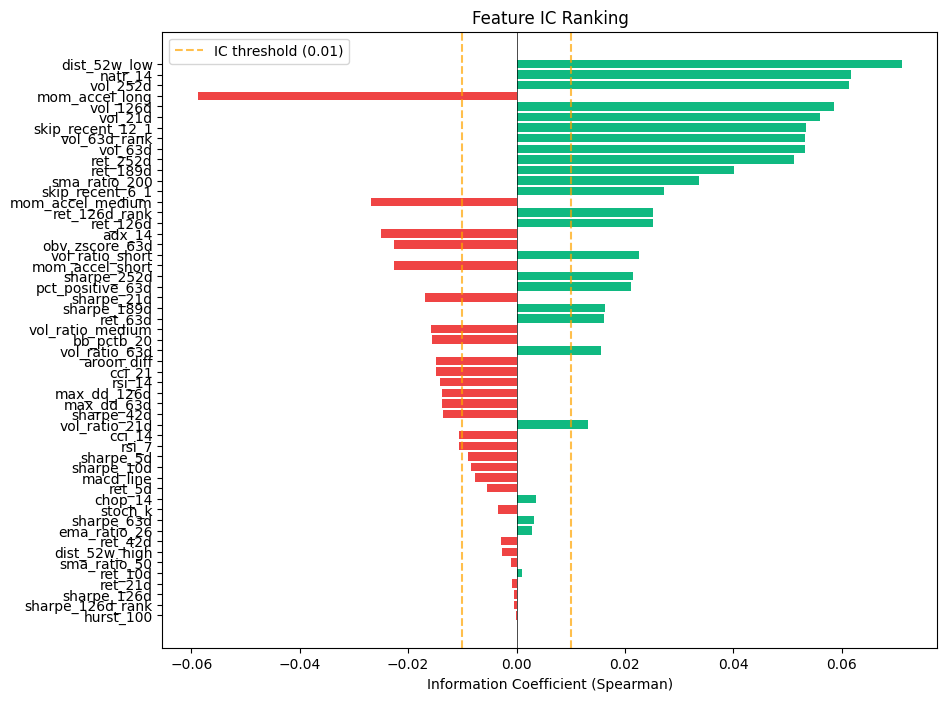

In [8]:
# IC bar chart
fig, ax = plt.subplots(figsize=(10, 8))
ic_pd = ic_df.to_pandas().sort_values("ic_abs", ascending=True)
colors = [COLORS["positive"] if ic > 0 else COLORS["negative"] for ic in ic_pd["ic"]]
ax.barh(ic_pd["feature"], ic_pd["ic"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
# Reference line at the |IC| threshold used for the final selection in §6, so
# the ranking chart and the selection step agree (features kept in §6 sit at or
# beyond this line).
ax.axvline(0.01, color="orange", linestyle="--", alpha=0.7, label="IC threshold (0.01)")
ax.axvline(-0.01, color="orange", linestyle="--", alpha=0.7)
ax.set_xlabel("Information Coefficient (Spearman)")
ax.set_title("Feature IC Ranking")
ax.legend()
plt.show()

## 3. Correlation Filtering

Highly correlated features provide overlapping information. We compute
correlation on the full panel (all dates × symbols), then remove features
with |r| > 0.9 — keeping the one with higher IC in each redundant pair.

In [9]:
feature_matrix = features_df.select(all_feature_cols).drop_nulls()
corr_np = feature_matrix.corr().to_numpy()

print(f"Correlation matrix: {corr_np.shape[0]} × {corr_np.shape[1]} features")

Correlation matrix: 57 × 57 features


### Remove Redundant Features
Greedily drop the weaker member of each highly correlated pair.

In [10]:
def filter_correlated_features(
    corr_matrix: np.ndarray,
    feature_names: list[str],
    ic_scores: dict[str, float] | None = None,
    threshold: float = 0.9,
) -> tuple[list[str], list[str]]:
    """Remove highly correlated features, keeping the one with higher IC."""
    removed = set()
    n = len(feature_names)

    for i in range(n):
        if feature_names[i] in removed:
            continue
        for j in range(i + 1, n):
            if feature_names[j] in removed:
                continue
            if abs(corr_matrix[i, j]) > threshold:
                if ic_scores:
                    ic_i = abs(ic_scores.get(feature_names[i], 0))
                    ic_j = abs(ic_scores.get(feature_names[j], 0))
                    to_remove = feature_names[j] if ic_i >= ic_j else feature_names[i]
                else:
                    to_remove = feature_names[j]
                removed.add(to_remove)

    kept = [f for f in feature_names if f not in removed]
    return kept, list(removed)

In [11]:
ic_scores = {row["feature"]: row["ic"] for row in ic_df.to_dicts()}

kept_after_corr, removed_by_corr = filter_correlated_features(
    corr_matrix=corr_np,
    feature_names=all_feature_cols,
    ic_scores=ic_scores,
    threshold=0.9,
)

print("Correlation Filtering (threshold=0.9):")
print(f"  Before: {len(all_feature_cols)} features")
print(f"  After:  {len(kept_after_corr)} features")
print(f"  Removed: {removed_by_corr}")

Correlation Filtering (threshold=0.9):
  Before: 57 features
  After:  46 features
  Removed: ['sma_ratio_50', 'ret_126d', 'rsi_7', 'cci_21', 'vol_21d', 'vol_126d', 'cci_14', 'vol_ratio_21d', 'stoch_k', 'vol_63d', 'ret_252d']


## 4. Clustering and Deduplication

Even after removing pairs above 0.9, many features remain near-duplicates.
Hierarchical clustering groups similar features so we can pick one
representative per cluster — preserving diversity across families while
removing redundancy within them.

**Linkage choice**: We use **complete linkage** (not Ward) because Ward
assumes Euclidean distance, which correlation-based distances do not satisfy.
Complete linkage also avoids the chaining that average linkage produces on
this panel, where many features share moderate correlations; it yields compact
clusters whose members are mutually near-duplicate.

In [12]:
# Cluster only features that carry a cross-sectional IC; the date-level series
# excluded from the ranking have no meaningful correlation structure to group.
cluster_features = [f for f in kept_after_corr if f in ic_scores]

# Build correlation matrix for the clustered features
surv_idx = [all_feature_cols.index(f) for f in cluster_features]
surv_corr = corr_np[np.ix_(surv_idx, surv_idx)]

# Distance = 1 - |ρ| (NaN correlations treated as uncorrelated → distance 1.0)
dist_matrix = 1 - np.abs(np.nan_to_num(surv_corr, nan=0.0))
np.fill_diagonal(dist_matrix, 0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2
dist_matrix = np.clip(dist_matrix, 0, 2)

dist_condensed = squareform(dist_matrix, checks=False)
link = linkage(dist_condensed, method="complete")

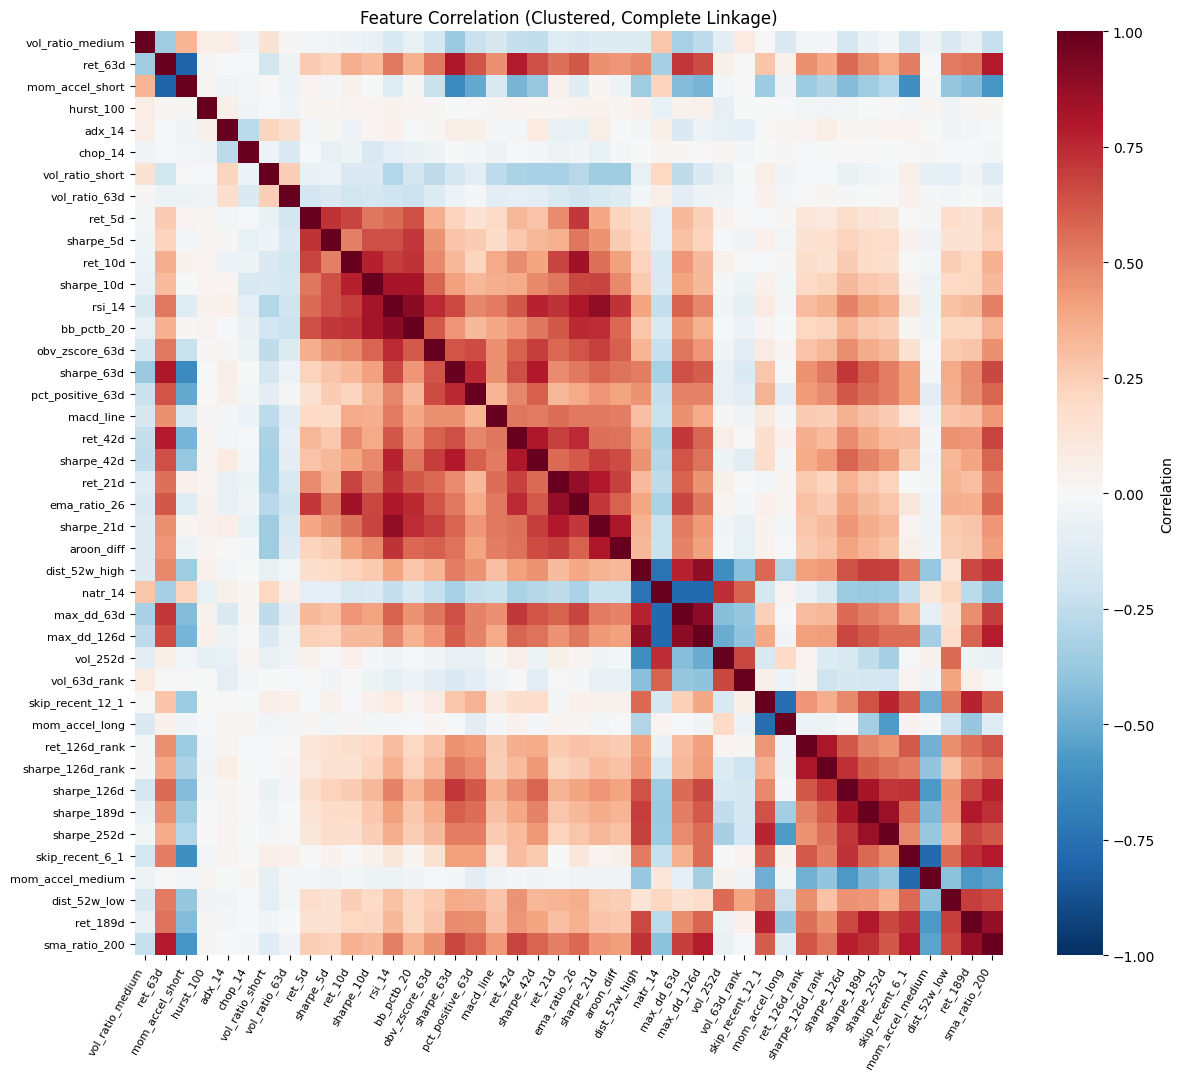

In [13]:
# Clustered heatmap
leaves = leaves_list(link)
reordered_names = [cluster_features[i] for i in leaves]
reordered_corr = surv_corr[np.ix_(leaves, leaves)]

fig, ax = plt.subplots(figsize=(14, 12))
n_feats = len(reordered_names)
sns.heatmap(
    reordered_corr,
    annot=(n_feats <= 25),
    fmt=".2f",
    annot_kws={"size": 6},
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    xticklabels=reordered_names,
    yticklabels=reordered_names,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Feature Correlation (Clustered, Complete Linkage)")
ax.tick_params(axis="both", labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.show()

The block structure reveals which features are essentially measuring the
same thing. Within each block, correlations are high, confirming that one
representative per cluster captures the shared signal. Between blocks,
correlations are lower, marking genuine diversification.

In [14]:
# Assign clusters and select representatives by highest |IC|
N_CLUSTERS = 10
clusters = fcluster(link, N_CLUSTERS, criterion="maxclust")

print(f"\n=== Factor Clusters ({N_CLUSTERS} groups) ===\n")
representatives = []

for c in range(1, N_CLUSTERS + 1):
    cluster_factors = [cluster_features[i] for i, clust in enumerate(clusters) if clust == c]
    if not cluster_factors:
        continue
    best = max(cluster_factors, key=lambda f: abs(ic_scores[f]))
    representatives.append(best)

    print(f"Cluster {c}:")
    for f in cluster_factors:
        marker = "  →" if f == best else "   "
        print(f"  {marker} {f}: IC = {ic_scores[f]:.4f}")

print(f"\nRepresentatives: {representatives}")


=== Factor Clusters (10 groups) ===

Cluster 1:
      ret_63d: IC = 0.0161
    → mom_accel_short: IC = -0.0225
      vol_ratio_medium: IC = -0.0158
Cluster 2:
    → adx_14: IC = -0.0249
      chop_14: IC = 0.0035
Cluster 3:
    → vol_ratio_short: IC = 0.0226
Cluster 4:
    → vol_ratio_63d: IC = 0.0156
Cluster 5:
    → hurst_100: IC = -0.0000
Cluster 6:
      ret_5d: IC = -0.0054
      ret_10d: IC = 0.0010
      sharpe_5d: IC = -0.0089
      sharpe_10d: IC = -0.0083
      rsi_14: IC = -0.0141
    → bb_pctb_20: IC = -0.0156
Cluster 7:
      ret_21d: IC = -0.0008
      ret_42d: IC = -0.0028
      sharpe_21d: IC = -0.0169
      sharpe_42d: IC = -0.0135
      sharpe_63d: IC = 0.0033
      macd_line: IC = -0.0077
      aroon_diff: IC = -0.0148
      ema_ratio_26: IC = 0.0029
    → obv_zscore_63d: IC = -0.0226
      pct_positive_63d: IC = 0.0210
Cluster 8:
      vol_252d: IC = 0.0613
    → natr_14: IC = 0.0618
      max_dd_63d: IC = -0.0137
      max_dd_126d: IC = -0.0138
      dist_52w_high

## 5. Multiple Testing Correction (BH-FDR)

With many features tested, some appear significant by chance.
Benjamini–Hochberg FDR controls the expected false discovery rate.

**Inference**: the p-values fed into BH-FDR come from the **Newey-West HAC**
t-statistic on each feature's daily IC series (matching the table above and
the headline measure in `06_robustness_sensitivity.py`). The i.i.d. t-stat
would overstate significance because daily ICs share slow-moving common
factors and overlapping information sets.

In [15]:
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr

ic_pvalues = []
ic_feature_names = []
for col in all_feature_cols:
    # Reuse the same finiteness/variance guard as the IC ranking so degenerate
    # series do not contribute NaN p-values, which would still inflate BH's
    # denominator and tighten the per-rank threshold for every valid feature.
    daily_ics = finite_daily_ics(col)
    if daily_ics is None:
        continue
    nw = sm.OLS(daily_ics, np.ones(len(daily_ics))).fit(
        cov_type="HAC", cov_kwds={"maxlags": NW_MAXLAGS}
    )
    p_val = float(nw.pvalues[0])
    if not np.isfinite(p_val):
        continue
    ic_pvalues.append(p_val)
    ic_feature_names.append(col)

if ic_pvalues:
    bh_result = benjamini_hochberg_fdr(ic_pvalues, alpha=0.05, return_details=True)

    n_significant_raw = sum(p < 0.05 for p in ic_pvalues)
    n_significant_fdr = sum(bh_result["rejected"])

    print(f"Features tested:                 {len(ic_pvalues)}")
    print(f"Significant at p<0.05 (raw):     {n_significant_raw}")
    print(f"Significant after BH-FDR:        {n_significant_fdr}")
    print(f"False discoveries prevented:     {n_significant_raw - n_significant_fdr}")

    survivors = [ic_feature_names[i] for i, r in enumerate(bh_result["rejected"]) if r]
    if survivors:
        print("\nFeatures surviving FDR correction:")
        for f in survivors:
            print(f"  - {f}")

Features tested:                 53
Significant at p<0.05 (raw):     13
Significant after BH-FDR:        7
False discoveries prevented:     6

Features surviving FDR correction:
  - skip_recent_12_1
  - vol_21d
  - vol_126d
  - vol_252d
  - mom_accel_long
  - natr_14
  - dist_52w_low


## 6. Selection Pipeline

Applying the steps in sequence: correlation filtering removes obvious
redundancy, clustering reduces each near-duplicate family to a single
representative, and an IC threshold keeps the representatives with predictive
power.

In [16]:
# IC filtering applied to the cluster representatives from §4
IC_THRESHOLD = 0.01
kept_after_ic = [f for f in representatives if abs(ic_scores[f]) >= IC_THRESHOLD]

print(f"IC Filtering of representatives (|IC| >= {IC_THRESHOLD}):")
print(f"  Representatives: {len(representatives)} features")
print(f"  After IC filter: {len(kept_after_ic)} features")

IC Filtering of representatives (|IC| >= 0.01):
  Representatives: 10 features
  After IC filter: 9 features


In [17]:
# Rank the surviving representatives by |IC| (top-K cap)
TOP_K = 10
final_features = sorted(kept_after_ic, key=lambda f: abs(ic_scores[f]), reverse=True)[:TOP_K]

print(f"\nSelected Features ({len(final_features)}):")
for i, f in enumerate(final_features, 1):
    print(f"  {i:2d}. {f} (IC={ic_scores[f]:.4f})")


Selected Features (9):
   1. dist_52w_low (IC=0.0712)
   2. natr_14 (IC=0.0618)
   3. mom_accel_long (IC=-0.0588)
   4. adx_14 (IC=-0.0249)
   5. obv_zscore_63d (IC=-0.0226)
   6. vol_ratio_short (IC=0.0226)
   7. mom_accel_short (IC=-0.0225)
   8. bb_pctb_20 (IC=-0.0156)
   9. vol_ratio_63d (IC=0.0156)


## 7. Stability Selection via Bootstrap IC

Stability selection tests whether features remain important across bootstrap
samples. Features that rank highly in >80% of samples are considered stable.

> **Caveat**: The bootstrap below samples individual rows (date × symbol),
> pooling across dates. A more rigorous approach bootstraps by *date*
> (block bootstrap), preserving cross-sectional structure. The pooled
> version here is a quick filter; production systems should use
> time-aware resampling.

In [18]:
def bootstrap_ic(
    df: pl.DataFrame,
    feature_cols: list[str],
    return_col: str = "fwd_return_1m",
    n_bootstrap: int = 50,
    sample_frac: float = 0.8,
) -> pl.DataFrame:
    """Compute IC across bootstrap samples to assess stability.

    Uses the global numpy seed set in the preamble via ``set_global_seeds(SEED)``.
    """
    n_samples = len(df)
    sample_size = int(n_samples * sample_frac)

    results = {f: [] for f in feature_cols}

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, size=sample_size, replace=True)
        sample = df[indices.tolist()]
        y = sample[return_col].to_numpy()

        for col in feature_cols:
            x = sample[col].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 30:
                results[col].append(np.nan)
                continue
            ic = pooled_ic(x[mask], y[mask])
            results[col].append(ic)

    stability_data = []
    for col in feature_cols:
        ics = np.array(results[col])
        valid = ics[~np.isnan(ics)]
        if len(valid) == 0:
            continue
        stability_data.append(
            {
                "feature": col,
                "ic_mean": np.mean(valid),
                "ic_std": np.std(valid),
                "ic_ir": np.mean(valid) / (np.std(valid) + 1e-8),
                "positive_pct": np.mean(valid > 0) * 100,
            }
        )

    if not stability_data:
        return pl.DataFrame(
            {"feature": [], "ic_mean": [], "ic_std": [], "ic_ir": [], "positive_pct": []}
        )
    return pl.DataFrame(stability_data).sort("ic_ir", descending=True)

In [19]:
stability = bootstrap_ic(df=analysis, feature_cols=final_features, n_bootstrap=N_BOOTSTRAP)
print(f"Stability Selection ({N_BOOTSTRAP} bootstrap samples):")
stability

Stability Selection (50 bootstrap samples):


feature,ic_mean,ic_std,ic_ir,positive_pct
str,f64,f64,f64,f64
"""natr_14""",0.100963,0.004593,21.982227,100.0
"""dist_52w_low""",0.061082,0.00398,15.34903,100.0
"""vol_ratio_short""",0.02671,0.003956,6.751959,100.0
"""vol_ratio_63d""",0.021153,0.003419,6.186439,100.0
"""adx_14""",-0.000858,0.003825,-0.224229,46.0
"""mom_accel_short""",-0.002454,0.004566,-0.537363,26.0
"""mom_accel_long""",-0.005179,0.003568,-1.45152,4.0
"""bb_pctb_20""",-0.031091,0.003925,-7.921796,0.0
"""obv_zscore_63d""",-0.047563,0.003666,-12.97461,0.0


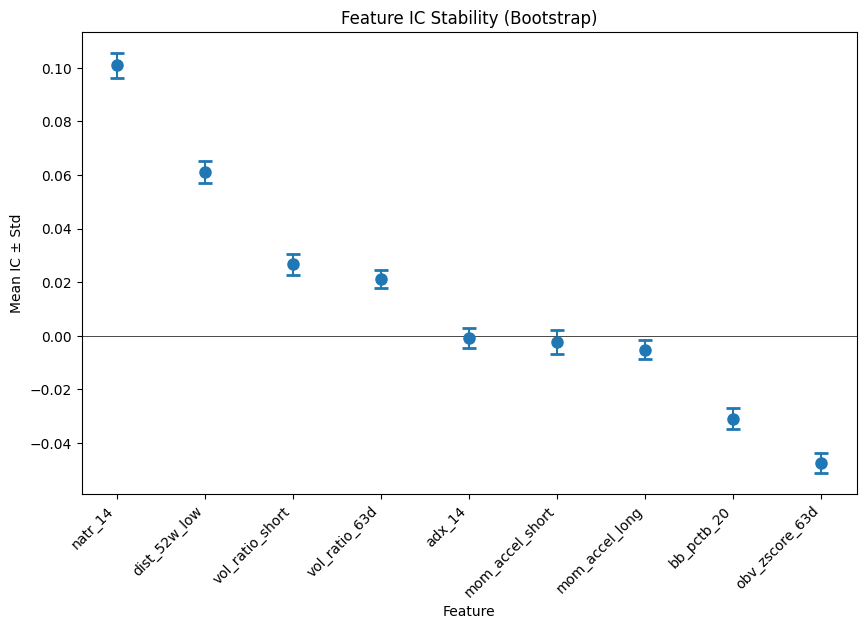

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
stab_pd = stability.to_pandas()
ax.errorbar(
    stab_pd["feature"],
    stab_pd["ic_mean"],
    yerr=stab_pd["ic_std"],
    fmt="o",
    capsize=5,
    capthick=2,
    markersize=8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Feature")
ax.set_ylabel("Mean IC ± Std")
ax.set_title("Feature IC Stability (Bootstrap)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 8. ML-Based Feature Importance

Beyond IC ranking, ML models identify features with non-linear predictive
power. We fit a quick LightGBM model and compare its feature importance
with the IC rankings above.

In [21]:
from ml4t.diagnostic.metrics import analyze_ml_importance

ml_data = analysis.select(["timestamp", "symbol"] + final_features + ["fwd_return_1m"]).drop_nulls()
X = ml_data.select(final_features).to_numpy()
y = ml_data["fwd_return_1m"].to_numpy()

if len(X) > 100:
    from lightgbm import LGBMRegressor

    lgbm = LGBMRegressor(n_estimators=100, max_depth=5, verbose=-1, random_state=SEED)
    lgbm.fit(X, y)

    importance_result = analyze_ml_importance(
        model=lgbm,
        X=X,
        y=y,
        feature_names=final_features,
        methods=["mdi", "pfi"],
    )

    print("=== ML Feature Importance (LightGBM) ===\n")
    print(f"Consensus top features: {importance_result['consensus_ranking'][:10]}")
    print(f"Methods run: {importance_result['methods_run']}")
    if importance_result.get("method_agreement"):
        print(f"Method agreement: {importance_result['method_agreement']}")
    print(f"\n{importance_result['interpretation']}")

=== ML Feature Importance (LightGBM) ===

Consensus top features: ['natr_14', 'mom_accel_long', 'vol_ratio_short', 'dist_52w_low', 'mom_accel_short', 'adx_14', 'obv_zscore_63d', 'bb_pctb_20', 'vol_ratio_63d']
Methods run: ['mdi', 'pfi']
Method agreement: {'mdi_vs_pfi': 0.9500000000000001}

Strong consensus: 9 features rank in top 10 across all methods
  Top consensus features: natr_14, mom_accel_long, vol_ratio_short, dist_52w_low, mom_accel_short
High agreement between methods (avg correlation: 0.95)


**Interpretation**: MDI (Mean Decrease in Impurity) measures how much each
feature reduces prediction error in the tree ensemble. PFI (Permutation
Feature Importance) measures how much shuffling a feature degrades
predictions. Features ranking high in both IC and ML importance are the
strongest candidates for production.

## 9. Post-Selection Verification

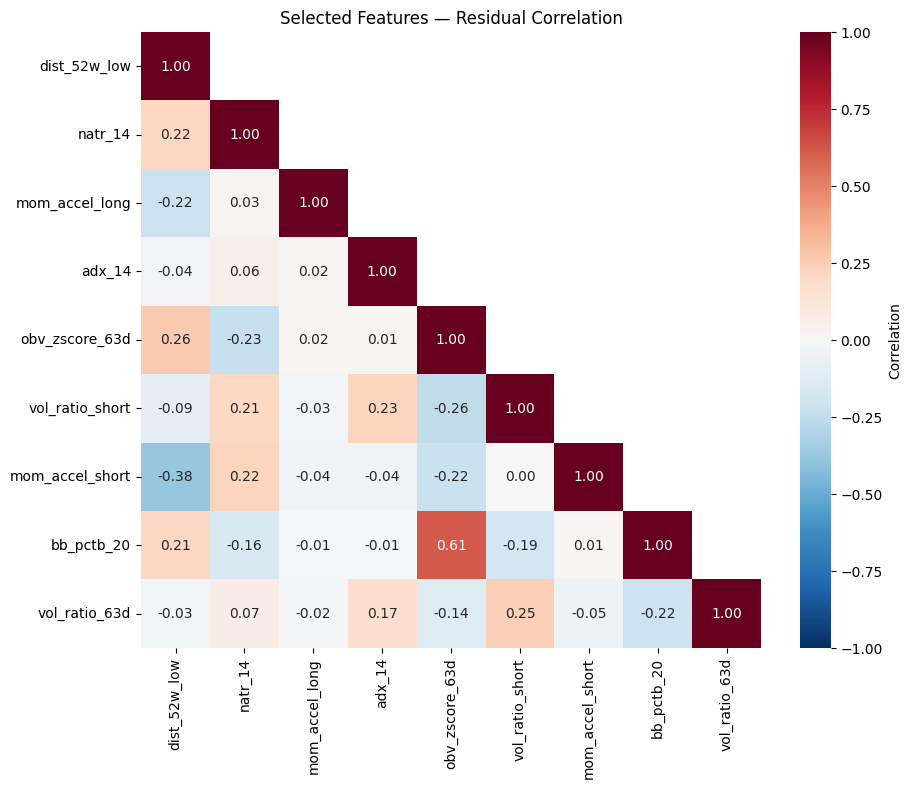

Max remaining correlation: 0.613


In [22]:
# Verify low inter-correlation among selected features
selected_matrix = features_df.select(final_features).drop_nulls()
corr_after = selected_matrix.corr().to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(
    corr_after,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    xticklabels=final_features,
    yticklabels=final_features,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Selected Features — Residual Correlation")
plt.show()

np.fill_diagonal(corr_after, 0)
max_corr = np.abs(corr_after).max()
print(f"Max remaining correlation: {max_corr:.3f}")

## 10. Selection Summary and Output

In [23]:
print("=" * 60)
print("FEATURE SELECTION REPORT")
print("=" * 60)
print(f"\nInitial Features:           {len(all_feature_cols)}")
print(f"After Correlation Filter:   {len(kept_after_corr)}")
print(f"Cluster Representatives:    {len(representatives)}")
print(f"After IC Filter:            {len(kept_after_ic)}")
print(f"Final Selected:             {len(final_features)}")
print(f"Removal Rate:               {100 * (1 - len(final_features) / len(all_feature_cols)):.1f}%")
print("\n" + "-" * 60)
print("SELECTED FEATURES FOR CHAPTER 9")
print("-" * 60)

for i, f in enumerate(final_features, 1):
    ic = ic_scores[f]
    stab_row = stability.filter(pl.col("feature") == f)
    ic_ir = stab_row["ic_ir"][0] if len(stab_row) > 0 else np.nan
    print(f"{i:2d}. {f:30s} IC={ic:+.4f}  IC_IR={ic_ir:.2f}")

print("=" * 60)

FEATURE SELECTION REPORT

Initial Features:           57
After Correlation Filter:   46
Cluster Representatives:    10
After IC Filter:            9
Final Selected:             9
Removal Rate:               84.2%

------------------------------------------------------------
SELECTED FEATURES FOR CHAPTER 9
------------------------------------------------------------
 1. dist_52w_low                   IC=+0.0712  IC_IR=15.35
 2. natr_14                        IC=+0.0618  IC_IR=21.98
 3. mom_accel_long                 IC=-0.0588  IC_IR=-1.45
 4. adx_14                         IC=-0.0249  IC_IR=-0.22
 5. obv_zscore_63d                 IC=-0.0226  IC_IR=-12.97
 6. vol_ratio_short                IC=+0.0226  IC_IR=6.75
 7. mom_accel_short                IC=-0.0225  IC_IR=-0.54
 8. bb_pctb_20                     IC=-0.0156  IC_IR=-7.92
 9. vol_ratio_63d                  IC=+0.0156  IC_IR=6.19


In [24]:
# Save selected features for Chapter 9
OUTPUT_DIR = get_output_dir(8, "feature_selection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selected_df = pl.DataFrame(
    {"feature": final_features, "ic": [ic_scores[f] for f in final_features]}
)
selected_df.write_parquet(OUTPUT_DIR / "selected_features.parquet")

filtered_features = features_df.select(["timestamp", "symbol"] + final_features)
filtered_features.write_parquet(OUTPUT_DIR / "features_selected.parquet")

print(f"Saved selected features to {OUTPUT_DIR}")
print(f"  - selected_features.parquet: {len(final_features)} features")
print(f"  - features_selected.parquet: {filtered_features.shape}")

Saved selected features to /tmp/ml4t-test-output/ch08_feature_selection
  - selected_features.parquet: 9 features
  - features_selected.parquet: (92101, 11)


## Key Takeaways

1. **Cross-sectional IC** is the correct method for factor evaluation —
   pooled IC conflates time-series drift with predictive power
2. **Correlation filtering** (|r| > 0.9) removes obvious redundancy;
   **clustering** catches subtler near-duplicates within feature families
3. **Use average or complete linkage** (not Ward) for correlation distances —
   Ward assumes Euclidean geometry
4. **BH-FDR with HAC-adjusted p-values** controls false discovery when
   screening many candidates. The p-values fed into BH-FDR come from the
   Newey-West t-statistic on each feature's daily IC series, not the
   i.i.d. t-stat, because daily ICs are serially correlated. Without
   multiple-testing correction, ~5% of null features appear significant
   at the 5% level by chance alone
5. **Bootstrap stability** separates features with robust IC from those
   that depend on a few outlier periods
6. Features ranking high in both IC and ML importance are the strongest
   production candidates

**Next**: `06_robustness_sensitivity` — parameter sensitivity and
regime-conditional analysis